# Photon Calibration Tutorial

This notebook walks through a complete photon-calibration workflow using the
current `Analyzer`, `Semiautocut`, and `PhotonCalibration` tools.

We will go through the analysis in the same order you would typically follow
when working with a real dataset:

1. inspect the available files and understand which inputs are needed,
2. extract `dP/dI` from a dIdV / IV analysis and save it to a filter file,
3. load the processed calibration dataset with `Analyzer`,
4. build a small set of quality cuts using `Semiautocut`,
5. fit the photon spectrum,
6. define a cut around one photon peak,
7. load raw traces for that peak and build average templates.

The emphasis here is on **clarity and reproducibility** rather than squeezing
everything into the fewest possible lines of code.


In [1]:
from detanalysis import PhotonCalibration, Analyzer, Semiautocut, MasterSemiautocuts
from detprocess import DIDVAnalysis, filterdata

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

# Adjust this base path for your local environment.
# base_path = '/data/ucb/pylelab'
base_path = '/sdata2/runs'

# Processed feature dataframe used for event selection and spectrum fitting.
proc_path = f'{base_path}/run68/processed/continuous_I2_D20260119_T165249/feature_calib_I2_D20260120_T193442'

# Raw continuous dataset used when loading traces later in the notebook.
raw_path = f'{base_path}/run68/raw/continuous_I2_D20260119_T165249'


## 1. Inputs and file layout

In this example we work with a laser calibration dataset. The relevant inputs are:

- **continuous / calibration raw data**, used to read traces,
- **processed feature data**, used for event selection and spectrum fitting,
- **IV / dIdV results**, used to calculate `dP/dI`,
- a **filter file**, where we store the `dP/dI` result for later template work.

The exact directory structure will vary from one setup to another, but the
analysis logic is the same.


## 2. Build a filter file with `dP/dI`

`PhotonCalibration` works in the power domain, so we first need a calibrated
`dP/dI` for the channel of interest.

The next few cells show one way to do that:

1. process a dIdV dataset,
2. load the matching IV sweep results,
3. fit the dIdV model,
4. calculate small-signal parameters,
5. evaluate `dP/dI` on the frequency grid corresponding to the template length,
6. save the result into a filter file.

If you already have a suitable filter file, you can skip ahead to the
`Analyzer` / `PhotonCalibration` sections.


In [2]:
# dIdV input file and series name for the channel we want to calibrate.
didv_path = f'{base_path}/run68/raw/continuous_I2_D20260119_T165249/didv_bor_I2_D20260119_T170334_F0001.hdf5'
continuous_path = f'{base_path}/run68/raw/continuous_I2_D20260119_T165249/'
didv_series = 'I2_D20260119_T170334'

DIDV = DIDVAnalysis()

# Process the raw dIdV data.
DIDV.process_raw_data(
    channels='lbldmd1_1right',
    files_or_path=continuous_path,
    series=didv_series,
)


INFO: Getting raw data and processing channel lbldmd1_1right


In [3]:
# Load the IV sweep results needed to extract the detector bias parameters.
iv_sweep_path = f'{base_path}/run68/filterdata/iv_didv_I2_D20260117_T102801/ivsweep_analysis_D20260118_T104259.hdf5'

DIDV.set_ivsweep_results_from_file(
    channels='lbldmd1_1right',
    file_name=iv_sweep_path,
    include_bias_parameters=True,
)

# Optional: pull the results into a Python object for inspection.
iv_sweep_results = DIDV.get_ivsweep_results(channel='lbldmd1_1right')


INFO: Loading filter data from file /sdata2/runs/run68/filterdata/iv_didv_I2_D20260117_T102801/ivsweep_analysis_D20260118_T104259.hdf5



lbldmd1_1right dIdV Fit Plots:


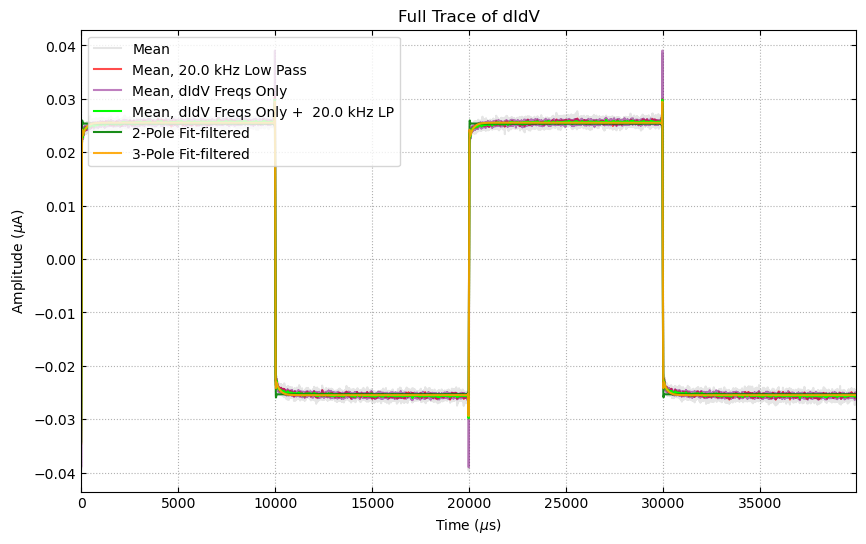

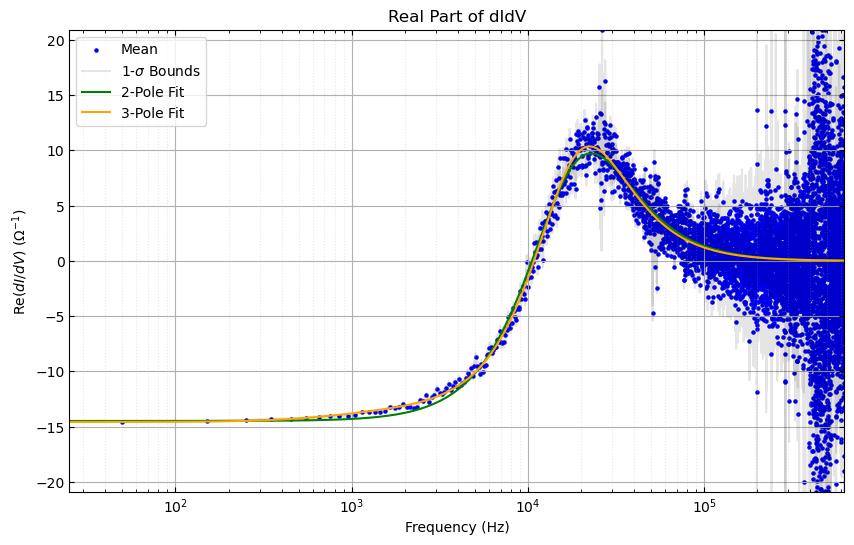

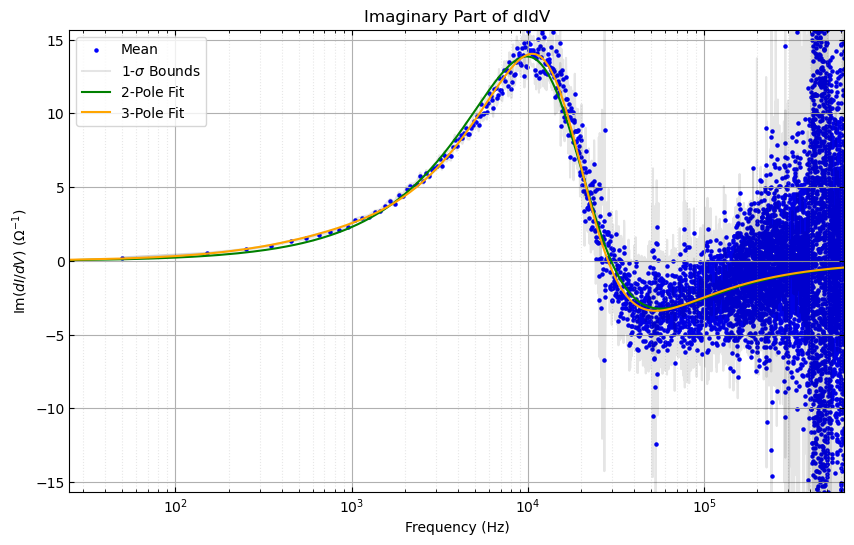

In [4]:
# Fit the dIdV model and show the time / frequency-domain result.
DIDV.dofit(
    list_of_poles=[2, 3],
    channels=['lbldmd1_1right'],
)
DIDV.plot_fit_result(channels=['lbldmd1_1right'])


In [5]:
# Compute the small-signal parameters derived from the dIdV fit.
DIDV.calc_smallsignal_params()


Calculating small signal parameters...
INFO: Calculating small signal parameters uncertainties for channel lbldmd1_1right
INFO: Using ibias=7.440e-06 A from IV sweep for channel lbldmd1_1right
INFO: Calculating small signal parameters for 2-poles model 
INFO: Calculating small signal parameters for 3-poles model 


In [6]:
# Evaluate dP/dI on the frequency grid matching the template length we want to use.
fs = 1.25e6
trace_length_sec = 0.010
freqs = np.fft.fftfreq(int(trace_length_sec * fs), 1 / fs)

DIDV.calc_dpdi(
    freqs,
    channels=['lbldmd1_1right'],
    list_of_poles=[2, 3],
)


In [7]:
# Save the result to a filter file. If you already have one, you can reuse it.
DIDV.save_hdf5(file_name = './test_didv_ff.hdf5',       
               overwrite = True)


INFO: Saving filter/TES data to file ./test_didv_ff.hdf5! (overwrite=True)


### Optional check: inspect the saved filter file

This is not strictly required, but it is a useful sanity check. We confirm that
the expected `dP/dI` objects were written to the file before moving on.


In [8]:
import pytesio as h5io

filter_io = h5io.FilterH5IO('./test_didv_ff.hdf5')
didv_dataframe = filter_io.load()


In [9]:
# Many objects are stored in the filter file.
# For this tutorial, the important ones are the dP/dI arrays and their uncertainties.
for key in didv_dataframe['lbldmd1_1right'].keys():
    print(key)


didv_results_2poles_biasparams_default
didv_results_2poles_biasparams_default_metadata
didv_results_2poles_errors_default
didv_results_2poles_errors_default_metadata
didv_results_2poles_fit_default
didv_results_2poles_fit_default_metadata
didv_results_2poles_params_default
didv_results_2poles_params_default_metadata
didv_results_2poles_smallsignalparams_default
didv_results_2poles_smallsignalparams_default_metadata
didv_results_2poles_ssp_light_default
didv_results_2poles_ssp_light_default_metadata
didv_results_3poles_biasparams_default
didv_results_3poles_biasparams_default_metadata
didv_results_3poles_errors_default
didv_results_3poles_errors_default_metadata
didv_results_3poles_fit_default
didv_results_3poles_fit_default_metadata
didv_results_3poles_params_default
didv_results_3poles_params_default_metadata
didv_results_3poles_smallsignalparams_default
didv_results_3poles_smallsignalparams_default_metadata
didv_results_3poles_ssp_light_default
didv_results_3poles_ssp_light_default_m

## 3. Load the processed calibration dataset

At this stage we switch from the raw / dIdV side of the analysis to the
processed calibration dataset.

`Analyzer` is the central object here:

- `analyzer.df_full` is the master dataframe,
- cuts are registered explicitly with `analyzer.register_cut(...)`,
- filtered working views are created with `analyzer.apply_global_filter(...)`.

For cut construction, it is safest to work on `analyzer.df_full` so that the
resulting masks always have the correct length for registration.


In [10]:
# Load the processed calibration feature dataframe.
analyzer = Analyzer(proc_path)
analyzer.describe()


Number of files: 3
Number of events in current df: 179290
Number of events in full df: 179290
Number of features: 66
Is DataFrame filtered? False
No cuts have been registered!
No derived features have been added!


In [11]:
# Build a small set of quality cuts.
#
# We work on analyzer.df_full so that the returned masks have the correct
# full-dataset length for analyzer.register_cut(...).

cut_pars_baseline = {'sigma_upper': 2.0}

baseline_cut = Semiautocut(
    analyzer.df_full,
    cut_rq='baseline_pre',
    channel_name='lbldmd1_1right',
    cut_pars=cut_pars_baseline,
)
bcut_mask = baseline_cut.do_cut(lgcdiagnostics=False)
analyzer.register_cut(bcut_mask, 'cut_baseline_pre_lbldmd1_1right')

# Create a derived slope feature, then cut on it.
slope = analyzer.df_full['baseline_pre_lbldmd1_1right'] - analyzer.df_full['baseline_end_lbldmd1_1right']
analyzer.add_feature(slope, 'slope_lbldmd1_1right')

cut_pars_slope = {'sigma': 2.0}
slope_cut = Semiautocut(
    analyzer.df_full,
    cut_rq='slope',
    channel_name='lbldmd1_1right',
    cut_pars=cut_pars_slope,
)
scut_mask = slope_cut.do_cut(lgcdiagnostics=False)
analyzer.register_cut(scut_mask, 'cut_slope_lbldmd1_1right')

# Combine the basic quality cuts into one master cut.
cuts_list = [
    'cut_baseline_pre_lbldmd1_1right',
    'cut_slope_lbldmd1_1right',
]

MSAC = MasterSemiautocuts(analyzer.df_full, cuts_list, 'lbldmd1_1right')
cut_all = MSAC.combine_cuts(cut_name='cut_all')
analyzer.register_cut(cut_all, 'cut_all')

print(f"Events passing cut_all: {np.count_nonzero(cut_all)}")


Events passing cut_all: 156851


In [12]:
# Initialize the PhotonCalibration object.
PC = PhotonCalibration(
    template_model='threepole',        # pulse model used in the power domain
    photon_energy_ev=3.04,             # laser photon energy in eV
    analyzer_object=analyzer,          # processed calibration dataset
    filterfile_path='./test_didv_ff.hdf5',
    npoles=3,                          # choose the 3-pole dP/dI result from the filter file
    dpdi_tag='default',
    channel_name='lbldmd1_1right',
    trace_length_sec=10e-3,
    pretrigger_window_sec=5e-3,
)


## 4. Fit the photon spectrum

We now fit a simple multi-Gaussian model to an OF-amplitude spectrum.

There are three main modeling choices:

1. **number of peaks** to include,
2. whether the **peak areas should follow Poisson statistics**,
3. whether the **peak spacing should be constrained to be equal**.

For a tutorial notebook, a simple model is usually enough. If the fit is not
perfect, that is okay: the point is to demonstrate the workflow and provide a
reasonable starting point for real analyses.


Event amps: [3.86683078e-08 1.90415097e-08 6.03841624e-08 ... 6.34177801e-08
 6.79262642e-08 6.15890260e-08]
Number of events: 156851
 
Guess: [2e-08, 1.5e-09, 3e-09, 4e-09, 6e-09, 8e-09, 4000, 5000, 5000, 4000, 2000]
Guess: [2e-08, 1.5e-09, 3e-09, 4e-09, 6e-09, 8e-09, 4000, 5000, 5000, 4000, 2000]
Bounds lower: [1e-08, 7.5e-10, 1.5e-09, 2e-09, 3e-09, 4e-09, 1000.0, 1250.0, 1250.0, 1000.0, 500.0]
Bounds upper: [3.0000000000000004e-08, 2.25e-09, 4.5e-09, 6.000000000000001e-09, 9e-09, 1.2000000000000002e-08, 8000.0, 10000.0, 10000.0, 8000.0, 4000.0]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.6174e+04                                    3.18e+04    
       1              2         1.7988e+04      8.19e+03       2.00e+03       4.31e+04    
       2              3         1.3233e+04      4.75e+03       1.67e+03       3.16e+04    
       3              4         1.3086e+04      1.47e+02       2.76e+02       2.17

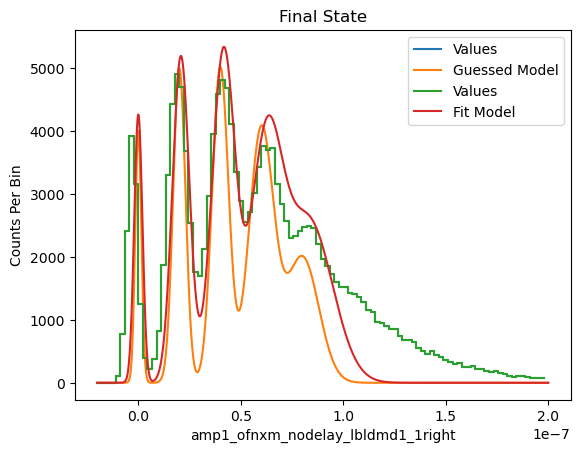

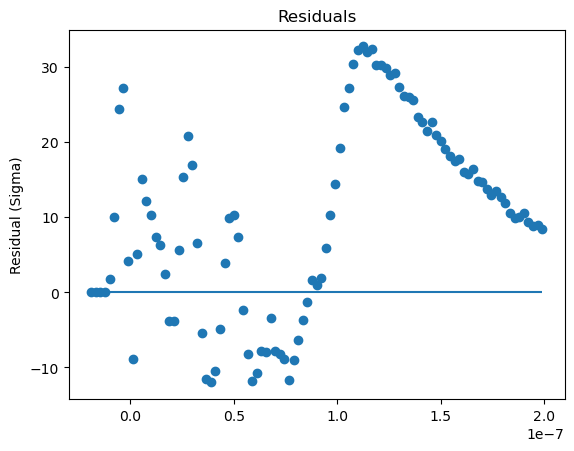

 
-----------
Fit Results: 
Peak spacing: 2.0775824054500148e-08 +/- 1.988431653376427e-11
Peak 0 width: 2.0072542170081715e-09 +/- 9.346944808047778e-11
Peak 0 height: 4261.364798809617 +/-217.45182133593676
Peak 1 width: 4.127902832819057e-09 +/- 4.964548726554354e-11
Peak 1 height: 5186.794807970629 +/-65.39529072906738
Peak 2 width: 5.607398006243101e-09 +/- 5.672616179315045e-11
Peak 2 height: 5227.983830776895 +/-56.076705934095266
Peak 3 width: 7.74268689903633e-09 +/- 8.628028347674653e-11
Peak 3 height: 3661.2428637671223 +/-41.12541890502818
Peak 4 width: 1.164043625584515e-08 +/- 1.358584945844504e-10
Peak 4 height: 2567.464958637122 +/-29.446101496226035


In [13]:
# Fit the OF-amplitude spectrum for the events that passed our quality cut.
#
# The initial guess does not need to be perfect, but a reasonable guess
# makes the fit much more stable.

guess = [
    2e-8,                               # single-photon amplitude spacing
    1.5e-9, 3e-9, 4e-9, 6e-9, 8e-9,     # peak widths
    4000, 5000, 5000, 4000, 2000,       # peak heights
]

_ = PC.fit_spectrum(
    'amp1_ofnxm_nodelay_lbldmd1_1right',  # amplitude-like energy proxy
    'cut_all',                            # quality cut defined above
    lgc_plot=True,
    lgc_diagnostics=True,
    poisson=False,
    eqspacing=True,
    npeaks=5,
    lgc_ylog=False,
    guess=guess,
    bounds=None,
    bins=np.linspace(-2e-8, 2e-7, 100),
)


## 5. Select one photon peak and load traces

After fitting the spectrum, we define a cut around one peak (here the
single-photon peak), then load the corresponding raw traces.

This section is where the analysis starts to look like template-building rather
than event selection:

- define a peak cut in OF-amplitude space,
- read the raw traces for the selected events,
- inspect a few example pulses,
- compute average traces and frequency-domain templates.


Peak center: 2.0775824054500148e-08
Width to cut: 3.0959271246142927e-09
 


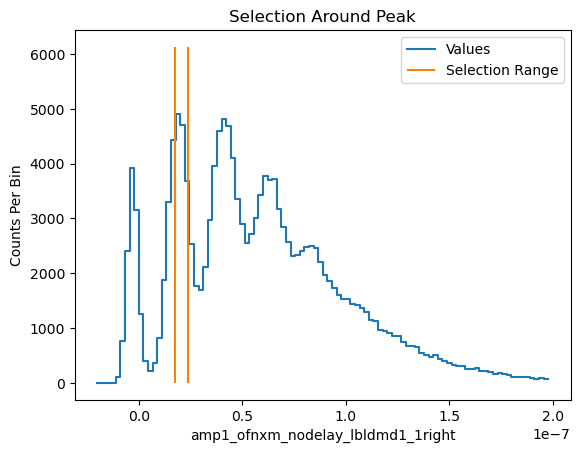

include_previous_cuts: False
 
 
include_previous_cuts: False
Using default cut parameters
Previous cut list: []
Cut parameters: {'val_lower': 1.7679896929885856e-08, 'val_upper': 2.387175117911444e-08}
Number of events passing base mask: 179290
Lower limit for cuts: 1.7679896929885856e-08
Upper limit for cuts: 2.387175117911444e-08


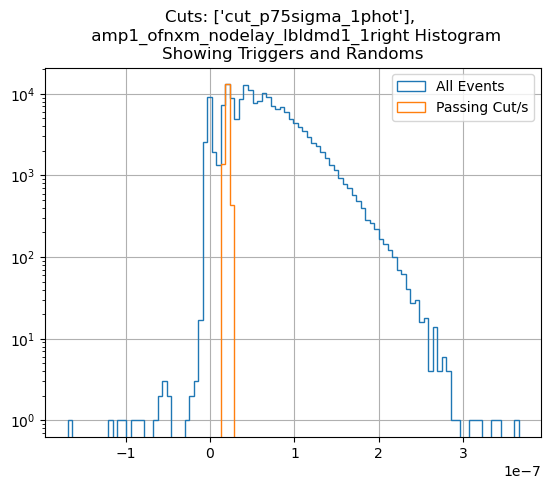

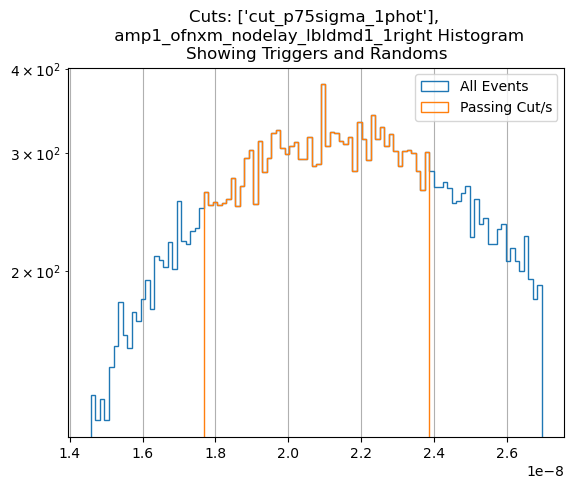

In [14]:
# Define a cut around the single-photon peak.
#
# The exact width is analysis-dependent. Here we keep the selection simple
# for tutorial purposes.

PC.define_photon_cut(
    1,                   # photon peak number
    0.75,                # half-width in units of sigma
    'cut_p75sigma_1phot',
    lgc_diagnostics=True,
)


Photon cut name: cut_p75sigma_1phot
INFO: Number of events found = 3000


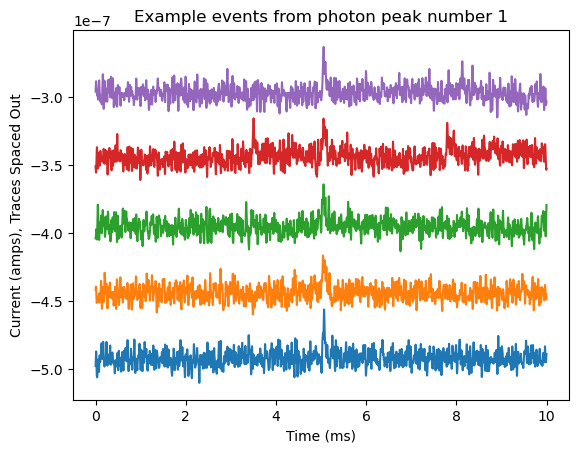

In [15]:
# Load a sample of raw traces passing the photon-peak cut and plot a few examples.
PC.load_events(
    1,                        # photon peak number
    number_events_limit=3000,
    pretrigger_window=5e-3,
    trace_length=10e-3,
    raw_path=f'{base_path}/run68/raw/continuous_I2_D20260119_T165249/',
    lgc_plot_example_events=True,
    example_events_num=5,
)


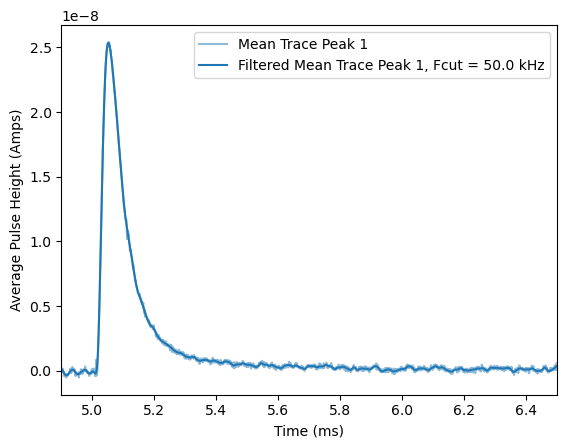

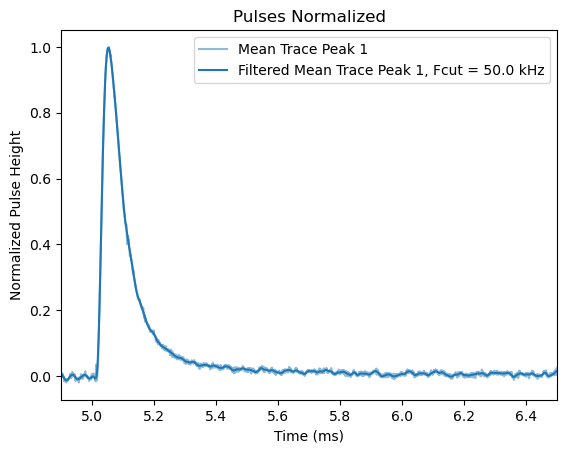

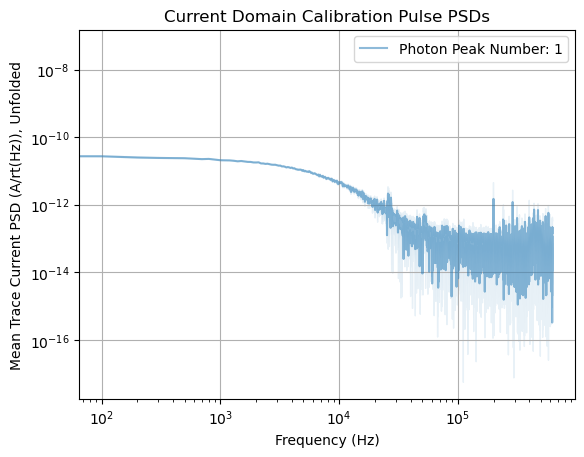

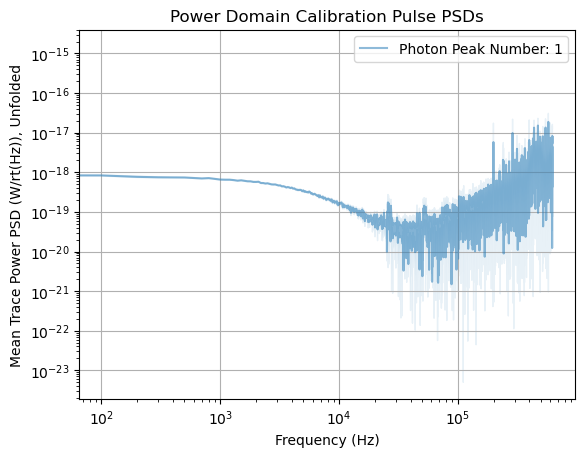

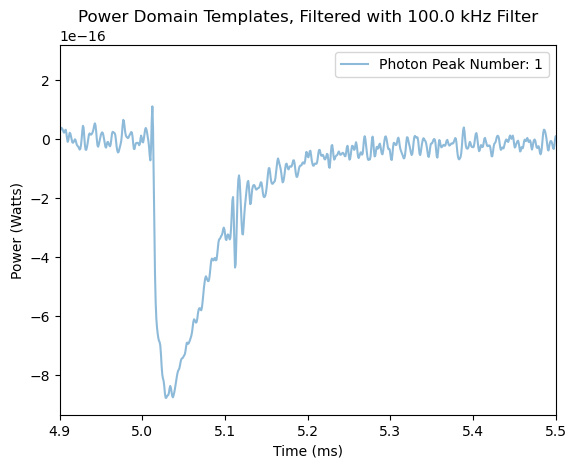

In [16]:
# Compute average pulses in the time domain and then build the corresponding
# frequency-domain templates.

PC.calculate_average_pulses(
    lgc_plot_average_trace=True,
    time_lims=[4.9e-3, 6.5e-3],
)

PC.calculate_frequency_domain_templates(
    lgc_plot=True,
    filter_freq=100e3,
)


Guess: [1.4e-15, 0, 6e-05, 0.0001, 1e-05]
Bounds is None


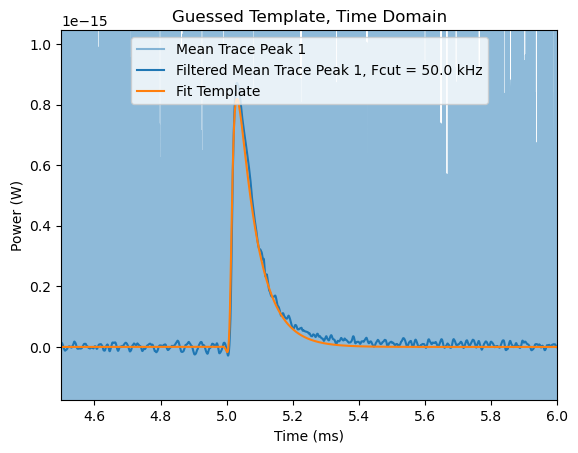

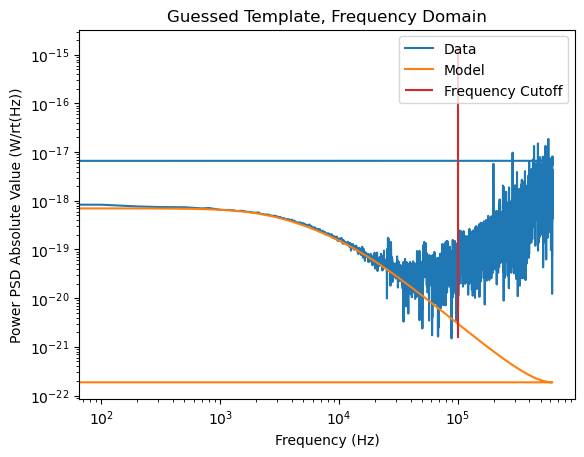

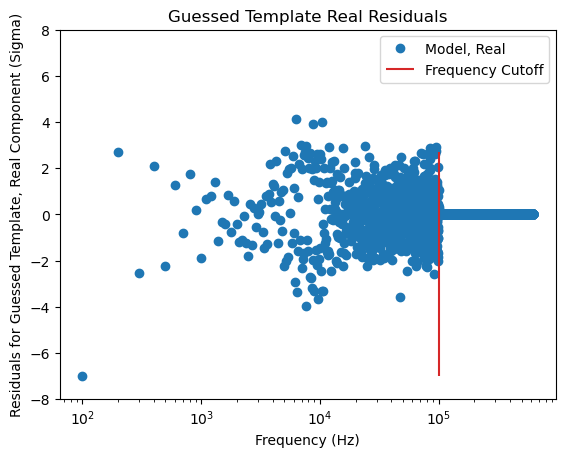

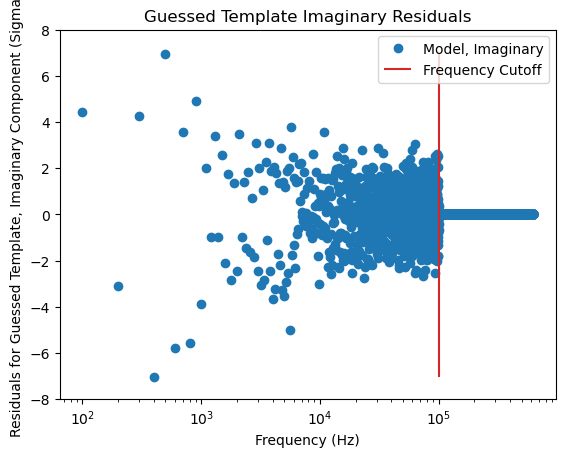

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0304e+03                                    1.70e+19    
       1              4         2.3397e+03      6.91e+02       7.32e-06       3.28e+18    
       2              6         2.2503e+03      8.94e+01       3.66e-06       1.22e+18    
       3              7         2.2169e+03      3.35e+01       7.32e-06       4.15e+18    
       4              9         2.1560e+03      6.09e+01       1.83e-06       1.33e+18    
       5             10         2.1534e+03      2.52e+00       3.66e-06       2.71e+18    
       6             11         2.1352e+03      1.83e+01       9.14e-07       2.74e+17    
       7             12         2.1325e+03      2.71e+00       1.83e-06       1.47e+17    
       8             13         2.1286e+03      3.89e+00       3.66e-06       2.41e+17    
       9             14         2.1240e+03      4.57e+00       7.32e-06       1.27e+18    

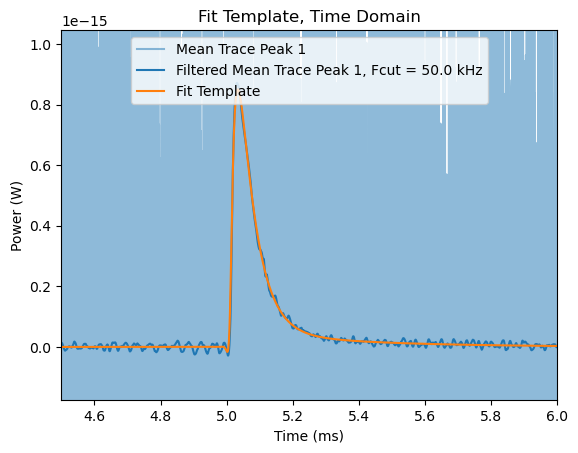

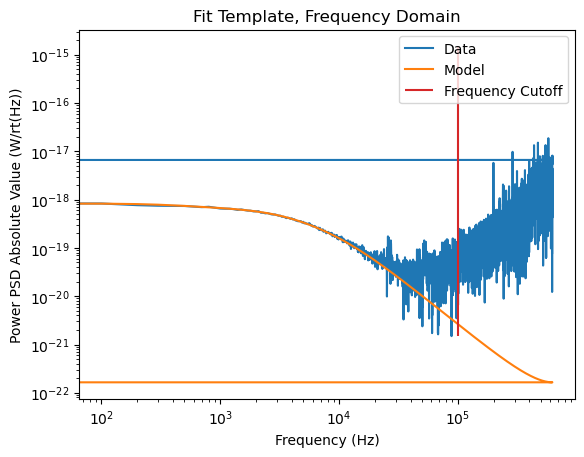

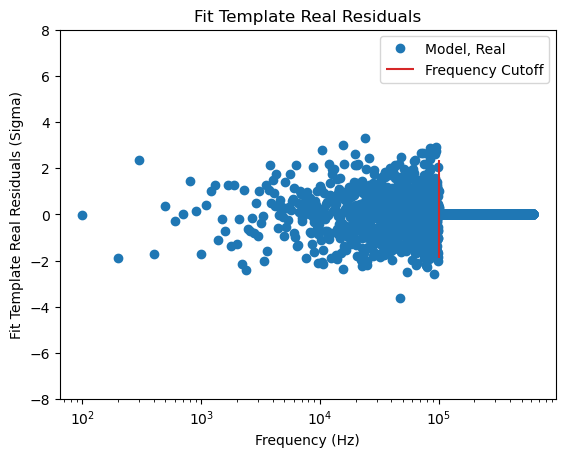

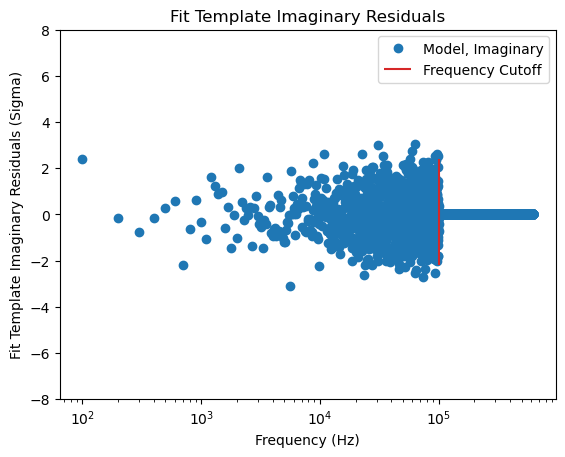

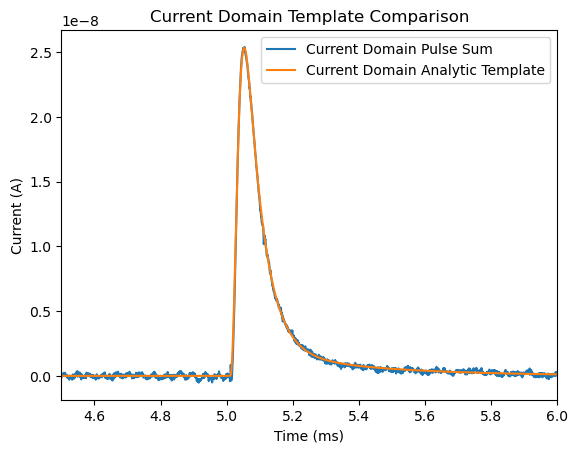

popt: 
[1.75931834e-15 5.67020524e-17 4.97930246e-05 3.43772541e-04
 1.31035838e-05]
 
cov:
[[ 4.89008099e-34  5.46857021e-35 -1.16680297e-23 -2.12563803e-22
   3.31541534e-24]
 [ 5.46857021e-35  2.49411722e-35 -2.44155169e-24 -1.21427904e-22
   4.02131826e-25]
 [-1.16680297e-23 -2.44155169e-24  3.57369392e-13  1.07046082e-11
  -7.86083293e-14]
 [-2.12563803e-22 -1.21427904e-22  1.07046082e-11  7.08655182e-10
  -1.68504332e-12]
 [ 3.31541534e-24  4.02131826e-25 -7.86083293e-14 -1.68504332e-12
   2.46831135e-14]]
 
Amplitude 1: 1.7593183416608769e-15 +/- 2.2113527515945292e-17
Amplitude 2: 5.670205238461605e-17 +/- 4.994113757268033e-18
Fall Time 1: 49.79302458987464 +/- 0.597803807048921 us
Fall Time 2: 343.7725411942645 +/- 26.620578174703766 us
Rise Time: 13.10358378709219 +/- 0.1571086040123915 us


In [17]:
# Fit the power-domain template model.
#
# We adjust dt slightly by hand to absorb a small timing offset before fitting.

PC.dt = 1e-5

PC.fit_templates(
    1,                          # photon peak number
    guess=[1.4e-15, 0, 6e-5, 1e-4, 1e-5],
    f_fit_cutoff=100e3,         # suppress high-frequency noise in the fit
    filter_freq=50e3,
    time_lims=[4.5e-3, 6e-3],
)


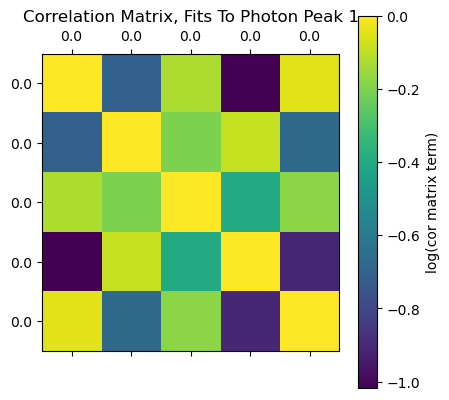

In [18]:
# Visualize correlations between fitted template parameters.
PC.get_correlation_matrix_visualization(photon_peak_number=1)


## 6. Summary quantities

At this point we can extract the quantities that motivated the analysis:

- the energy resolution inferred from the fitted spectrum,
- the phonon collection efficiency from the fitted template,
- the current-domain template for downstream use.

These final cells are intentionally short: most of the work was in preparing
clean selections and stable templates.


In [19]:
# Extract a few final summary quantities from the fitted spectrum and template.
_ = PC.get_spectrum_energy_res()

print()

_ = PC.get_template_phonon_collection_effiency(photon_peak_number=1)


5 fit
Inter-peak spacing is assumed to be uniform
Measuring energy resolution using single-photon energy
and peak width relative to peak spacing in OFAmp
 
Energy resolution: 0.6040109205223941 +/- 0.007264322266656943 eV

Energy in template: 8.329250722323001e-20 +/- 6.734629462295461e-22 J
Energy in template: 0.5199118300874017 +/- 0.004203755710364827 eV
Photon Energy in Peak: 4.87008e-19 J
Phonon Collection Efficiency: 0.17102903283566184 +/- 0.001382858076724707


Text(0, 0.5, 'Amplitude')

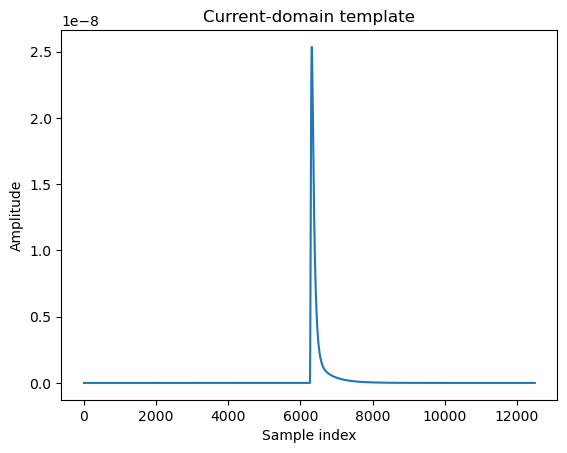

In [20]:
# Retrieve the current-domain template for downstream use.
template = PC.get_current_template(
    photon_peak_number=1,
    lgc_plot=False,
)

fig, ax = plt.subplots()
ax.plot(template)
ax.set_title("Current-domain template")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude")


In [21]:
# Show the cuts currently registered in the Analyzer.
analyzer.list_cuts()


['cut_baseline_pre_lbldmd1_1right',
 'cut_slope_lbldmd1_1right',
 'cut_all',
 'cut_p75sigma_1phot']

## Final remarks

This tutorial showed the full chain from detector response calibration
(`dP/dI`) to photon-spectrum fitting and template extraction.

In real analyses you will often iterate on:
- the quality cuts,
- the spectrum model and initial guesses,
- the width of the photon-peak selection,
- the template fit model and frequency cutoff.

A good practical strategy is to first make the workflow stable and readable,
then refine the physics details once the analysis chain is easy to rerun.
